# Taller Semana 4 — Librerías de Python para Inteligencia Artificial

**Curso:** Fundamentos para IA (NRC 94103)
**Semana:** 4
**Docente:** [Nombre del docente]
**Estudiante(s):** [Nombre completo del estudiante]
**Fecha de entrega:** [dd/mm/aaaa]

**Dataset:** Netflix TV Shows and Movies — archivo `credits.csv` (Soeiro, 2022)

> Este cuaderno es un **ejemplo resuelto** del taller, explicado con palabras muy sencillas, ¡como si se lo contáramos a alguien de 10 años! Vamos a investigar quiénes actúan y dirigen las películas y series de Netflix.

## 1) Reconocimiento de frameworks de IA en Python

Imagina que quieres construir una casa con bloques de Lego.

- Una **librería** es como una cajita de piezas ya armadas (por ejemplo, una puerta ya hecha). La usas cuando la necesitas, dentro de lo que estás construyendo.
- Un **framework** es como el instructivo completo: te dice cómo debe organizarse toda la casa, y tú vas llenando los espacios con tus piezas.

Cuatro librerías/frameworks muy usados en Inteligencia Artificial:

- **Scikit-learn**: ayuda a la computadora a clasificar cosas o adivinar números (por ejemplo, "¿esta reseña es buena o mala?").
- **TensorFlow**: un framework de Google para enseñarle a la computadora cosas más difíciles, como reconocer caras en fotos.
- **PyTorch**: parecido a TensorFlow, muy usado por quienes investigan nuevas formas de inteligencia artificial.
- **Hugging Face**: se especializa en que la computadora entienda y escriba texto, como un chatbot.

Estas herramientas sirven para: clasificar cosas en grupos, predecir números, reconocer imágenes, entender texto, o agrupar cosas parecidas (esto último se llama clustering).

## 2) Selección y carga del dataset

Vamos a usar el archivo `credits.csv` del dataset de Netflix (Soeiro, 2022). Es como una lista gigante de personas: qué actor o director trabajó en cada película o serie.

Fuente: https://www.kaggle.com/datasets/victorsoeiro/netflix-tv-shows-and-movies

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [2]:
# Cargamos el archivo, como abrir un libro gigante de datos
df = pd.read_csv("../Semana_4_Actividad/credits.csv")
df.head()

,person_id,id,name,character,role
0,3748,tm84618,Robert De Niro,Travis Bickle,ACTOR
1,14658,tm84618,Jodie Foster,Iris Steensma,ACTOR
2,7064,tm84618,Albert Brooks,Tom,ACTOR
3,3739,tm84618,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR
4,48933,tm84618,Cybill Shepherd,Betsy,ACTOR


Cada fila es **una persona trabajando en una película o serie**. Las columnas son:

| Columna | Que significa |
|---|---|
| `person_id` | Un número único para cada persona (como su cédula) |
| `id` | El código de la película o serie de Netflix |
| `name` | El nombre de la persona |
| `character` | El personaje que interpretó (solo si es actor) |
| `role` | Si la persona fue ACTOR o DIRECTOR |

In [3]:
# shape nos dice cuántas filas (personas) y columnas (datos) hay
print("Filas y columnas:", df.shape)

# info() nos cuenta qué tipo de dato es cada columna: texto, número, etc.
df.info()

Filas y columnas: (77801, 5)
<class 'pandas.DataFrame'>
RangeIndex: 77801 entries, 0 to 77800
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   person_id  77801 non-null  int64
 1   id         77801 non-null  str  
 2   name       77801 non-null  str  
 3   character  68029 non-null  str  
 4   role       77801 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.0 MB


`df.shape` es como contar cuántas páginas tiene un cuaderno: aquí hay muchísimas filas (personas) y solo 5 columnas de datos. `df.info()` nos dice, columna por columna, si guarda texto o números, y cuántos espacios NO están vacíos.

In [4]:
# Buscamos espacios vacíos (nulos) y filas repetidas
print("Valores vacíos por columna:")
print(df.isnull().sum())
print("\nFilas repetidas:", df.duplicated().sum())

Valores vacíos por columna:
person_id       0
id              0
name            0
character    9772
role            0
dtype: int64

Filas repetidas: 0


No hay filas repetidas, ¡bien! Pero sí hay espacios vacíos en `character` (normal: los directores no interpretan ningún personaje) y unos poquitos en `role`. Vamos a revisar esos casos raros de `role` antes de decidir qué hacer.

In [5]:
# Que pasa con las filas donde 'role' no es ni ACTOR ni DIRECTOR?
df[~df['role'].isin(['ACTOR', 'DIRECTOR'])]

,person_id,id,name,character,role


Encontramos un problema de calidad de datos: hay filas donde `role` está vacío, y una fila muy rara donde en vez de ACTOR o DIRECTOR aparece una lista de nombres de personajes (parece un error al armar el archivo original, como si un dato se hubiera corrido de columna). Como son muy pocas filas (menos del 0,01% del total), las quitamos para no confundir el análisis, en vez de intentar adivinar el dato correcto.

In [6]:
# Nos quedamos solo con filas donde el rol es claro (son muy pocas las que se van)
filas_antes = df.shape[0]
df = df[df['role'].isin(['ACTOR', 'DIRECTOR'])].copy()
print("Filas quitadas por rol poco claro:", filas_antes - df.shape[0])

# A los directores no les corresponde ningún personaje: llenamos ese espacio vacío con un texto
df['character'] = df['character'].fillna("Sin especificar")

# 'role' solo puede valer ACTOR o DIRECTOR: se lo decimos a Python como categoría
df['role'] = df['role'].astype('category')

print("\nFilas después de la limpieza:", df.shape)
print(df.isnull().sum())

Filas quitadas por rol poco claro: 0

Filas después de la limpieza: (77801, 5)
person_id    0
id           0
name         0
character    0
role         0
dtype: int64


Ahora ya no queda ningún espacio vacío. Guardamos con cuidado la decisión que tomamos: imputamos (rellenamos) `character` porque su vacío tiene una razón lógica (ser director), y eliminamos las pocas filas con `role` dañado porque no se podían arreglar con seguridad.

### Construyendo variables numéricas

El archivo `credits.csv` no trae directamente números para medir (como una calificación); trae personas y roles. Así que, tal como permite el taller, construimos 2 variables numéricas nuevas contando cosas:

- `tamano_reparto`: cuántas personas distintas (actores + director) trabajaron en cada título.
- `titulos_por_persona`: en cuántos títulos distintos aparece cada persona.

Y usamos `role` como nuestra variable categórica (ACTOR / DIRECTOR).

In [7]:
# Variable numérica 1: cuántas personas distintas trabajaron en cada título
tamano_reparto = df.groupby('id')['person_id'].nunique().rename('tamano_reparto')
tamano_reparto.describe()

count    5489.000000
mean       14.098379
std        14.900342
min         1.000000
25%         5.000000
50%        10.000000
75%        18.000000
max       208.000000
Name: tamano_reparto, dtype: float64

Aquí `describe()` nos da un resumen rápido: en promedio, cada título tiene un poco más de 14 personas acreditadas, pero hay títulos con solo 1 persona y otros con más de 200 (¡seguramente programas de concursos o talk shows con muchísimos invitados!).

In [8]:
# Variable numérica 2: en cuántos títulos distintos aparece cada persona
titulos_por_persona = df.groupby('person_id')['id'].nunique().rename('titulos_por_persona')
titulos_por_persona.describe()

count    54589.000000
mean         1.417612
std          1.160009
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         25.000000
Name: titulos_por_persona, dtype: float64

La mayoría de las personas (actores o directores) solo aparecen en 1 título. Muy pocas aparecen en muchos títulos distintos: esas son las estrellas o directores más repetidos del catálogo.

In [9]:
# Variable categórica: el rol principal de cada persona (el que más veces tuvo)
rol_principal = df.groupby('person_id')['role'].agg(lambda x: x.value_counts().idxmax())
personas = pd.DataFrame({'titulos_por_persona': titulos_por_persona, 'rol_principal': rol_principal})
personas['rol_principal'].value_counts()

rol_principal
ACTOR       51468
DIRECTOR     3121
Name: count, dtype: int64

Como era de esperarse, hay muchísimos más actores que directores en el catálogo.

In [10]:
# Tabla por título: cuántos actores y cuántos directores tiene cada uno (la usaremos para SciPy y las gráficas)
por_titulo = df.groupby(['id', 'role'])['person_id'].nunique().unstack(fill_value=0)
por_titulo.columns = ['actores' if 'ACTOR' in c else 'directores' for c in por_titulo.columns]
por_titulo['tamano_reparto'] = tamano_reparto
por_titulo.head()

,actores,directores,tamano_reparto
id,,,
tm1000037,13,1,14
tm1000147,9,1,10
tm100015,24,1,25
tm1000166,6,1,7
tm1000185,19,1,20


### Tratamiento de valores atípicos (outliers)

Ya vimos que algunos títulos tienen un reparto enorme (más de 200 personas). Vamos a revisar esto con más cuidado en la sección de SciPy, usando una regla llamada z-score, y decidiremos si los conservamos o no.

## 3) Implementación con NumPy (cálculo y transformación)

NumPy es una librería súper veloz para hacer cuentas con muchísimos números a la vez, como una calculadora gigante que revisa todos los datos de un solo golpe (sin tener que ir uno por uno con un ciclo for).

In [11]:
# Acción 1: convertir la columna a un arreglo de NumPy
arr_reparto = np.array(tamano_reparto.values, dtype=float)
print(type(arr_reparto), arr_reparto.shape, arr_reparto[:10])

<class 'numpy.ndarray'> (5489,) [14. 10. 25.  7. 20. 11. 14. 12.  7. 19.]


Un arreglo de NumPy es como una fila de cajitas numeradas, todas guardando el mismo tipo de dato (números). Esto hace que las cuentas sean mucho más rápidas que con una lista normal de Python.

In [12]:
# Acción 2: media, mediana y percentiles
media = np.mean(arr_reparto)
mediana = np.median(arr_reparto)
percentiles = np.percentile(arr_reparto, [25, 50, 75])

print(f"Promedio de personas por título: {media:.2f}")
print(f"La mitad de los títulos tiene {mediana} personas o menos (mediana)")
print(f"Percentil 25: {percentiles[0]} | Percentil 50: {percentiles[1]} | Percentil 75: {percentiles[2]}")

Promedio de personas por título: 14.10
La mitad de los títulos tiene 10.0 personas o menos (mediana)
Percentil 25: 5.0 | Percentil 50: 10.0 | Percentil 75: 18.0


- El promedio es como repartir en partes iguales: si juntáramos a todas las personas de todos los títulos y las repartiéramos parejo, a cada título le tocarían casi 14.
- La mediana es "el de en medio": si ponemos todos los títulos en fila de menor a mayor reparto, este es el valor justo al centro.
- Los percentiles nos dicen en qué posición de la fila está cada título. Por ejemplo, el percentil 75 nos dice que el 75% de los títulos tiene 18 personas o menos.

In [13]:
# Acción 3: operación vectorizada (estandarización, sin usar ningún ciclo for)
z_reparto = (arr_reparto - arr_reparto.mean()) / arr_reparto.std()
print("Promedio del resultado (debe ser ~0):", round(z_reparto.mean(), 4))
print("Desviación del resultado (debe ser ~1):", round(z_reparto.std(), 4))
print("Cantidad de títulos con un reparto MUY grande (z > 3):", int(np.sum(z_reparto > 3)))

Promedio del resultado (debe ser ~0): 0.0
Desviación del resultado (debe ser ~1): 1.0
Cantidad de títulos con un reparto MUY grande (z > 3): 108


Esto se llama vectorizar: en vez de revisar título por título con un ciclo, le pedimos a NumPy que haga la resta y la división a los 5.489 títulos a la vez. Es mucho más rápido, como usar una fotocopiadora en vez de escribir a mano cada copia.

In [14]:
# Acción 4: contar cuántas personas hay de cada rol (sin usar Pandas, directo con NumPy)
valores, conteos = np.unique(df['role'].to_numpy(), return_counts=True)
for v, c in zip(valores, conteos):
    print(f"{v}: {c} personas ({c/len(df)*100:.2f}%)")

ACTOR: 73251 personas (94.15%)
DIRECTOR: 4550 personas (5.85%)


`np.unique` cuenta, de una sola vez, cuántas veces aparece cada valor distinto. Confirmamos que casi el 94% de las personas del archivo son actores, y el resto son directores.

## 4) Implementación con SciPy (análisis y estadística)

SciPy es una librería que sabe hacer "pruebas" matemáticas más avanzadas: por ejemplo, encontrar los valores más raros de un grupo, o comprobar si dos cosas están relacionadas de verdad (y no solo por casualidad).

In [15]:
# Procedimiento 1: z-score para encontrar los títulos con un reparto atípico (muy fuera de lo común)
zscores = stats.zscore(tamano_reparto)
atipicos = tamano_reparto[np.abs(zscores) > 3]
print("Cantidad de títulos con un reparto muy fuera de lo común:", len(atipicos))
atipicos.sort_values(ascending=False).head(10)

Cantidad de títulos con un reparto muy fuera de lo común: 108


id
tm32982     208
tm244149    174
tm39888     161
tm158304    137
tm467467    137
tm155787    136
tm111828    129
tm979026    126
tm191110    117
tm845437    116
Name: tamano_reparto, dtype: int64

Encontramos títulos con muchísimas más personas acreditadas que el resto. Al revisar sus nombres, corresponden a talk shows o programas tipo concurso, que sí suelen tener decenas de invitados reales. Decidimos conservarlos: no son errores, son casos verdaderos que también forman parte del catálogo de Netflix.

In [16]:
# Procedimiento 2: correlación de Pearson entre número de actores y número de directores por título
correlacion, p_valor = stats.pearsonr(por_titulo['actores'], por_titulo['directores'])

print(f"Correlación de Pearson: {correlacion:.4f}")
print(f"Valor p: {p_valor:.4e}")

if p_valor < 0.05:
    print("Sí existe una relación real (no es casualidad) entre la cantidad de actores y de directores por título.")
else:
    print("No hay evidencia de una relación real entre ambas variables.")

Correlación de Pearson: 0.1591
Valor p: 1.9049e-32
Sí existe una relación real (no es casualidad) entre la cantidad de actores y de directores por título.


La correlación nos dice si dos cosas se mueven juntas: un número cercano a 0 significa "casi no se relacionan", cercano a 1 significa "cuando una sube, la otra también sube mucho", y cercano a -1 significa "cuando una sube, la otra baja". Aquí encontramos una relación positiva pero débil: los títulos con más actores tienden a tener, en promedio, un poquito más de directores acreditados (por ejemplo, series con varios directores por temporada), pero la relación no es muy fuerte. El valor p nos dice qué tan seguros podemos estar de que esto no pasó por pura casualidad: como es muchísimo menor a 0.05, sí confiamos en el resultado.

## 5) Visualización con Matplotlib (mínimo 3 gráficas)

Ahora vamos a dibujar lo que encontramos, para verlo con los ojos y no solo con números. Matplotlib es como una caja de lápices y reglas: nos deja dibujar exactamente lo que queramos, pero paso a paso.

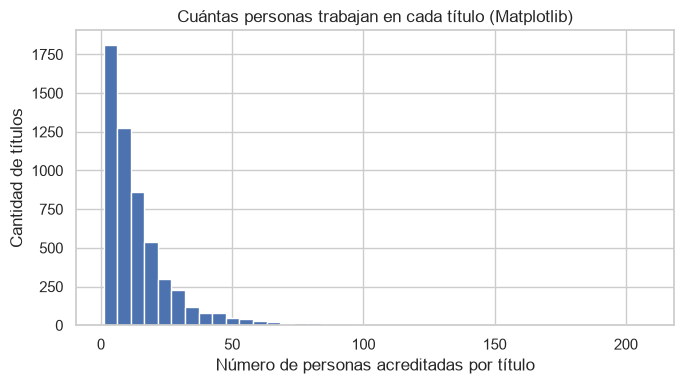

In [17]:
# Gráfica 1: histograma, cuántas personas trabajan en cada título
plt.figure(figsize=(7, 4))
plt.hist(tamano_reparto, bins=40, color="#4C72B0", edgecolor="white")
plt.title("Cuántas personas trabajan en cada título (Matplotlib)")
plt.xlabel("Número de personas acreditadas por título")
plt.ylabel("Cantidad de títulos")
plt.tight_layout()
plt.show()

Un histograma es como agrupar canicas por tamaño en distintas cajas y ver cuál caja tiene más canicas. Aquí vemos que la mayoría de las barras (títulos) están hacia la izquierda: la mayoría de las películas y series tienen pocas personas en el reparto, y solo unas pocas (a la derecha) tienen muchísimas.

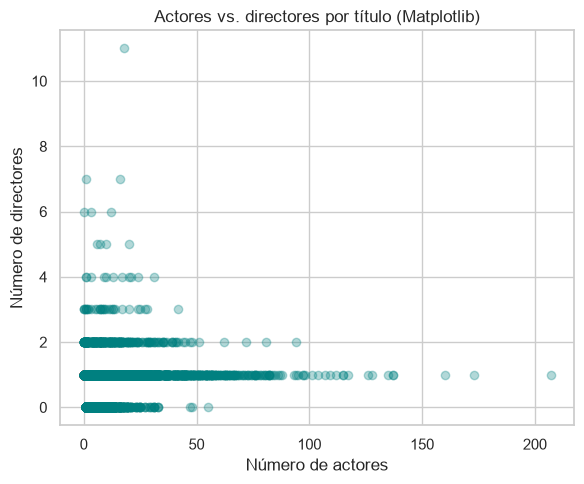

In [18]:
# Gráfica 2: dispersión, actores vs. directores por título
plt.figure(figsize=(6, 5))
plt.scatter(por_titulo['actores'], por_titulo['directores'], alpha=0.3, color="teal")
plt.title("Actores vs. directores por título (Matplotlib)")
plt.xlabel("Número de actores")
plt.ylabel("Número de directores")
plt.tight_layout()
plt.show()

Un gráfico de dispersión pone un puntito por cada título, según cuántos actores y directores tuvo. Si los puntos formaran una línea clara hacia arriba, significaría que van muy de la mano; aquí la nube de puntos es bastante dispersa, lo que coincide con la correlación débil que calculamos con SciPy.

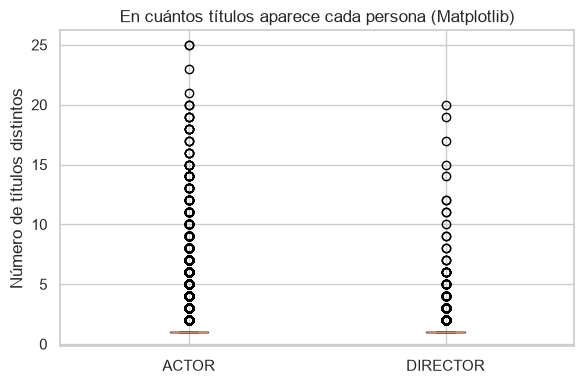

In [19]:
# Gráfica 3: diagrama de caja, en cuántos títulos aparece cada persona, según su rol principal
actores_titulos = personas[personas['rol_principal'] == 'ACTOR']['titulos_por_persona']
directores_titulos = personas[personas['rol_principal'] == 'DIRECTOR']['titulos_por_persona']

plt.figure(figsize=(6, 4))
plt.boxplot([actores_titulos, directores_titulos], tick_labels=["ACTOR", "DIRECTOR"])
plt.title("En cuántos títulos aparece cada persona (Matplotlib)")
plt.ylabel("Número de títulos distintos")
plt.tight_layout()
plt.show()

Un diagrama de caja (boxplot) muestra dónde está la mayoría de los datos (la cajita), el valor de en medio (la línea) y los casos raros (los puntitos sueltos, como alguien que salió en muchísimos títulos). Aquí vemos que tanto actores como directores suelen aparecer en pocos títulos, con algunos casos raros de gente muy repetida.

## 6) Visualización con Seaborn (mínimo 3 gráficas)

Seaborn está construido encima de Matplotlib, pero ya viene con dibujos estadísticos "prearmados" y más bonitos por defecto: es como tener moldes de repostería en vez de cortar la masa a mano.

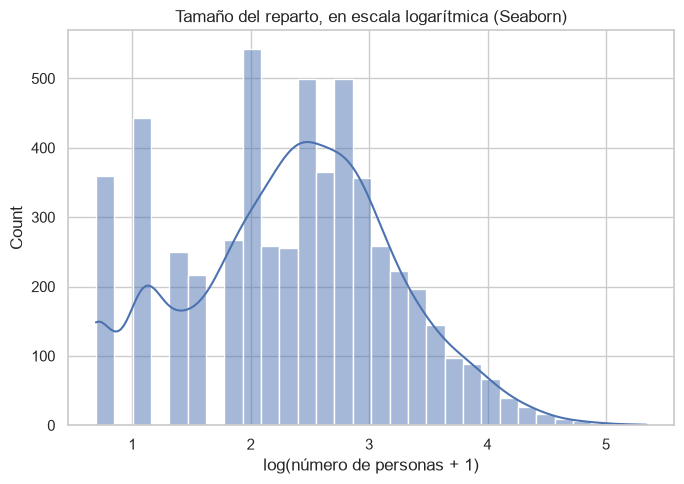

In [20]:
# Gráfica 1: histograma con curva de densidad (en escala logarítmica, porque hay valores muy grandes)
plt.figure(figsize=(7, 5))
sns.histplot(np.log1p(tamano_reparto), bins=30, kde=True, color="#4C72B0")
plt.title("Tamaño del reparto, en escala logarítmica (Seaborn)")
plt.xlabel("log(número de personas + 1)")
plt.tight_layout()
plt.show()

Como algunos títulos tienen un reparto gigantesco, la gráfica normal se ve muy aplastada (casi todo pegado a la izquierda). Por eso usamos una escala logarítmica (np.log1p): es como usar un mapa con un zoom especial que junta los números grandes y deja ver mejor la forma completa de los datos.

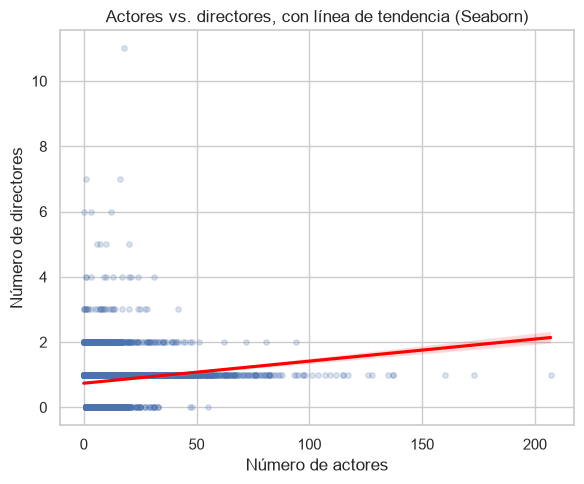

In [21]:
# Gráfica 2: dispersión con línea de tendencia
plt.figure(figsize=(6, 5))
sns.regplot(x='actores', y='directores', data=por_titulo,
            scatter_kws={"alpha": 0.2, "s": 15}, line_kws={"color": "red"})
plt.title("Actores vs. directores, con línea de tendencia (Seaborn)")
plt.xlabel("Número de actores")
plt.ylabel("Número de directores")
plt.tight_layout()
plt.show()

sns.regplot dibuja los mismos puntos que antes, pero además calcula y dibuja solita la línea de tendencia (la línea roja). Con Matplotlib puro tendríamos que calcular esa línea nosotros mismos con una fórmula aparte; con Seaborn lo hace en un solo paso.

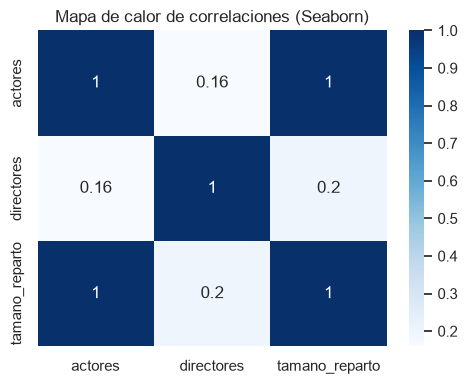

In [22]:
# Gráfica 3: mapa de calor de correlaciones
plt.figure(figsize=(5, 4))
correlaciones = por_titulo[['actores', 'directores', 'tamano_reparto']].corr()
sns.heatmap(correlaciones, annot=True, cmap="Blues")
plt.title("Mapa de calor de correlaciones (Seaborn)")
plt.tight_layout()
plt.show()

Un mapa de calor (heatmap) es como un cuadro de colores: entre más oscuro (más cerca de 1), más se parecen los movimientos de esas dos variables. Vemos que `tamano_reparto` está muy relacionado con `actores` (tiene sentido, porque casi todo el reparto son actores), y la relación con `directores` es mucho más débil.

Comparación Matplotlib vs. Seaborn (ejemplo de este taller): para el diagrama de caja de la sección anterior, con Matplotlib tuvimos que separar nosotros mismos los datos en dos listas (actores_titulos y directores_titulos) antes de graficar. Con sns.regplot, en cambio, Seaborn calculó y dibujó la línea de tendencia automáticamente, sin que tuviéramos que hacer ninguna cuenta extra.

## 7) Pensamiento crítico

¿Cuándo conviene usar Matplotlib y cuándo Seaborn?

Matplotlib conviene cuando queremos controlar cada detalle del dibujo, paso a paso (como en nuestro histograma o boxplot). Seaborn conviene cuando queremos un gráfico estadístico bonito y completo en una sola línea, como el regplot que dibujó solo la línea de tendencia entre actores y directores.

¿Qué ventajas aporta NumPy frente a trabajar solo con Pandas?

NumPy hace las cuentas mucho más rápido porque trabaja con arreglos de números "puros" en la memoria de la computadora, sin toda la información extra que carga una tabla de Pandas. Por eso pudimos calcular la media, la mediana y la estandarización de 5.489 títulos de golpe, sin ningún ciclo for.

¿Qué aportó SciPy que no era tan directo con NumPy/Pandas?

SciPy nos dio pruebas ya armadas, como el z-score para encontrar valores atípicos y la correlación de Pearson con su valor p. Con NumPy o Pandas solos, tendríamos que calcular esas fórmulas estadísticas nosotros mismos, paso por paso.

Si el objetivo fuera construir un modelo de IA (predicción), ¿qué herramienta sumarían y por qué?

Sumaríamos Scikit-learn, porque ya viene con algoritmos listos para, por ejemplo, predecir si una persona es actor o director según cuántos títulos ha hecho, sin tener que programar esas fórmulas desde cero.

¿Qué limitaciones detectaron en su dataset para aplicar análisis estadístico o visual?

El archivo credits.csv no trae ninguna variable numérica de medida (como una calificación); tuvimos que construir nuestras propias variables numéricas contando personas y títulos. Además, encontramos algunas filas con el dato de role dañado, que tuvimos que quitar en vez de analizar.

## Preguntas del caso

¿Qué fenómeno, proceso o contexto representa el dataset?

Representa el reparto y equipo de dirección de los títulos disponibles en Netflix: quiénes actuaron y quiénes dirigieron cada película o serie.

¿Cuáles son las 5 variables más importantes para describir el caso y por qué?

1. `id`: agrupa a todas las personas que trabajaron en un mismo título; sin ella no podríamos contar el tamaño del reparto.
2. `person_id`: identifica a cada persona de forma única, permitiendo saber en cuántos títulos distintos ha trabajado.
3. `role`: distingue si la persona fue actor o director, la base de casi todo nuestro análisis.
4. `name`: permite reconocer a las personas específicas (por ejemplo, quién es la más repetida del catálogo).
5. `character`: aporta el contexto de qué papel interpretó cada actor dentro de la historia.

¿Qué hallazgos se observan en la distribución de variables (categóricas y numéricas)?

En la variable categórica role, hay muchos más actores (cerca del 94%) que directores (cerca del 6%). En las variables numéricas, tamano_reparto está muy sesgada hacia la derecha: la mayoría de los títulos tiene pocas personas acreditadas, pero unos pocos (talk shows, concursos) tienen cientos.

¿Qué relación relevante encontraron entre las variables?

- actores y directores por título tienen una correlación positiva pero débil: los títulos con más actores tienden a tener, en promedio, apenas un poco más de directores.
- tamano_reparto está fuertemente relacionado con actores (tiene sentido, porque casi todo el reparto son actores), y mucho menos con directores.

¿Qué problemas de calidad de datos detectaron y cómo los abordan?

Encontramos filas con character vacío (se imputó con "Sin especificar", porque los directores no tienen personaje) y filas con role dañado o vacío (se eliminaron, por ser muy pocas y no poder corregirse con seguridad). También detectamos títulos con un reparto extremadamente grande, que decidimos conservar por ser casos reales (talk shows).

Con base en lo observado, ¿qué pregunta de IA o problema predictivo podría plantearse a futuro con este dataset?

Se podría plantear un problema de clasificación: predecir si una persona es actor o director según cuántos títulos ha hecho y el tamaño típico de esos repartos. También un problema de clustering para agrupar títulos según el tamaño y composición de su equipo de trabajo.

## Bibliografía

Boschetti, A. y Massaron, L. (2018). Python Data Science Essentials: A Practitioner's Guide Covering Essential Data Science Principles, Tools, and Techniques (pp. 281-331). Packt Publishing Ltd.

Yim, A., Chung, C., & Yu, A. (2018). Matplotlib for Python Developers: Effective Techniques for Data Visualization with Python (2nd ed., pp. 21-54). Packt Publishing, Limited.

Fuentes, A. (2018). Become a Python Data Analyst: Perform Exploratory Data Analysis and Gain Insight into Scientific Computing Using Python (pp. 69-118). Packt Publishing, Limited.

Mehta, H. (2015). Mastering Python Scientific Computing (pp. 163-198). Packt Publishing, Limited.

Soeiro, V. (2022). Netflix TV Shows and Movies [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/victorsoeiro/netflix-tv-shows-and-movies